# Employee Satisfaction & Attrition Prediction Pipeline

This notebook uses pandas (not Spark) for all data processing and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os
warnings.filterwarnings('ignore')

# Portable data path — looks for FEVS_2024_PRDF.csv in same folder, then common locations
candidates = [
    'FEVS_2024_PRDF.csv',
    os.path.expanduser('~/Downloads/ADTA5940-Capstone/FEVS_2024_PRDF.csv'),
    os.path.expanduser('~/Downloads/FEVS_2024_PRDF.csv'),
    os.path.expanduser('~/Downloads/FEVS/FEVS_2024_PRDF.csv'),
]
data_path = next((p for p in candidates if os.path.exists(p)), None)
if data_path is None:
    raise FileNotFoundError("Place FEVS_2024_PRDF.csv next to this notebook or in ~/Downloads/")

df = pd.read_csv(data_path, low_memory=False)
print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} columns from {data_path}")
df.head()


Loaded 674,207 rows x 96 columns from FEVS_2024_PRDF.csv


,RandomID,POSTWT,agency,level1,Q1,Q2,Q3,Q4,Q5,Q6,...,Q91,DRNO,DHISP,DDIS,DAGEGRP,DSUPER,DFEDTEN,DSEX,DMIL,DLEAVING
0,112970976817,1.597695,XX,XXZZ,3.0,4.0,4.0,4.0,1.0,NaN,...,2.0,B,B,B,B,B,B,A,B,D
1,194868625278,1.828360,XX,XXZZ,3.0,3.0,4.0,4.0,4.0,4.0,...,3.0,B,B,B,B,B,B,A,A,A
2,152966380283,1.867398,XX,XXZZ,2.0,1.0,3.0,3.0,3.0,2.0,...,3.0,B,B,B,B,A,A,A,A,A
3,193041162980,2.077359,XX,XXZZ,4.0,5.0,5.0,5.0,2.0,5.0,...,2.0,B,B,B,B,A,A,A,A,A
4,146655962451,1.494947,XX,XXZZ,4.0,4.0,4.0,4.0,4.0,4.0,...,3.0,B,B,A,B,B,C,A,A,A


In [2]:
# Explore the dataset
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nData Types:\n{df.dtypes.value_counts()}")
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Rows with Missing Data: {df.isnull().any(axis=1).sum():,}")

# Key variables
print("\n" + "="*50)
print("KEY VARIABLES FOR OUR MODEL")
print("="*50)

print("\n📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):")
q69_dist = pd.to_numeric(df['Q69'], errors='coerce').value_counts().sort_index()
print(q69_dist)
print(f"   Mean: {pd.to_numeric(df['Q69'], errors='coerce').mean():.2f}")

print("\n📊 Q61 — Telework Frequency (Independent Variable, 1-5):")
print(df['Q61'].value_counts().sort_index())

print("\n📊 Q64 — Work-Life Balance Satisfaction (1-5):")
print(df['Q64'].value_counts().sort_index())

print("\n📊 Demographics:")
print(f"   Age Groups:  {df['DAGEGRP'].value_counts().to_dict()}")
print(f"   Gender:      {df['DSEX'].value_counts().to_dict()}")
print(f"   Supervisory: {df['DSUPER'].value_counts().to_dict()}")
print(f"   Fed Tenure:  {df['DFEDTEN'].value_counts().to_dict()}")

Dataset Shape: 674,207 rows × 96 columns

Data Types:
object     51
float64    44
int64       1
Name: count, dtype: int64

Total Missing Values: 1,881,545
Rows with Missing Data: 312,355

KEY VARIABLES FOR OUR MODEL

📊 Q69 — Job Satisfaction (Dependent Variable, 1-5):
Q69
1.0     47350
2.0     79827
3.0    135145
4.0    236220
5.0    149365
Name: count, dtype: int64
   Mean: 3.56

📊 Q61 — Telework Frequency (Independent Variable, 1-5):
Q61
1     40062
2     39944
3    112405
4    206010
5    223382
X     31266
Name: count, dtype: int64

📊 Q64 — Work-Life Balance Satisfaction (1-5):
Q64
1     43756
2     59413
3    140093
4    230093
5    159368
X     19084
Name: count, dtype: int64

📊 Demographics:
   Age Groups:  {'B': 441972, 'A': 151314}
   Gender:      {'A': 269549, 'B': 256446}
   Supervisory: {'A': 494780, 'B': 133618}
   Fed Tenure:  {'A': 276499, 'B': 199531, 'C': 152612}


In [3]:
#Check column's percentage of missing values
missing_pct = df.isna().mean().sort_values(ascending=False)
print(missing_pct.head(20))

DSEX        0.219832
DRNO        0.207715
DHISP       0.130423
DAGEGRP     0.120024
DDIS        0.106596
DMIL        0.068019
DSUPER      0.067945
DFEDTEN     0.067583
DLEAVING    0.062160
Q40         0.045452
Q87         0.044559
Q89         0.043461
Q86         0.043187
Q88         0.041339
Q70         0.041029
Q90         0.040912
Q91         0.040729
Q68         0.040415
Q48         0.039301
Q69         0.039009
dtype: float64


#Handling Missing Values

In [4]:
# 1. Replace missing codes
df.replace(['XX', 'XXZZ', -1, -2], None, inplace=True)

# 2. Convert survey questions to numeric
q_cols = [col for col in df.columns if col.startswith('Q')]
df[q_cols] = df[q_cols].apply(pd.to_numeric, errors='coerce')

# 3. Median imputation
for col in q_cols:
    df[col] = df[col].fillna(df[col].median())

# 4. Categorical columns
cat_cols = ['DSEX', 'DSUPER', 'DFEDTEN','DAGEGRP']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [5]:
print(f"\nTotal Missing Values: {df.isnull().sum().sum():,}")
print(f"Rows with Missing Data: {df.isnull().any(axis=1).sum():,}")


Total Missing Values: 402,431
Rows with Missing Data: 148,581


In [6]:
df.isna().mean().sort_values(ascending=False).head(10)

DRNO        0.207715
DHISP       0.130423
DDIS        0.106596
DMIL        0.068019
DLEAVING    0.062160
agency      0.010991
level1      0.010991
Q52         0.000000
Q60         0.000000
Q59         0.000000
dtype: float64

In [7]:
#Drop all missing values in the target column
df = df[df['DLEAVING'].notna()]

In [8]:
# Create binary attrition column: 0 = Stay, 1 = Leave
df['DLEAVING_BIN'] = np.where(df['DLEAVING'] == 'A', 0, 1)

#understanding what drives leaving and how your features behave

It’s about answering:

“What makes employees leave?”

In [9]:
df['DLEAVING'].value_counts()
df['DLEAVING'].value_counts(normalize=True)

DLEAVING
A    0.661754
C    0.181331
B    0.118952
D    0.037963
Name: proportion, dtype: float64


A	No

B	Yes, to another federal job

C	Yes, to private sector

D	Yes, other (retirement, etc.)

<Axes: xlabel='DLEAVING'>

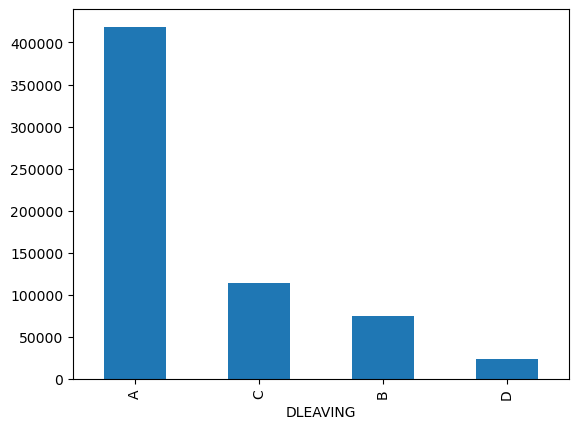

In [10]:
df['DLEAVING'].value_counts().plot(kind='bar')

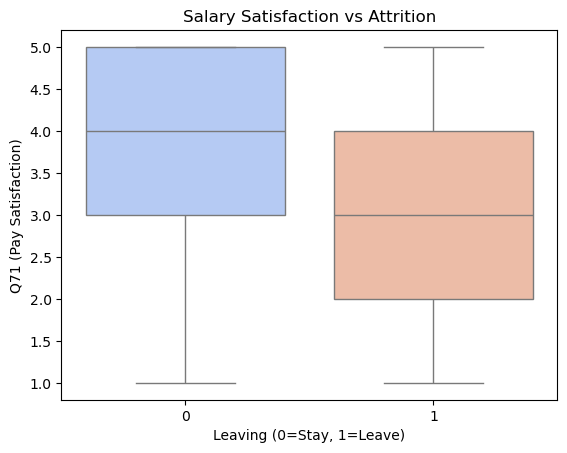

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.close('all')  # Close any previous figures

# Plot a random sample of 10,000 rows (adjust if needed)
sample_df = df.sample(10000, random_state=42) if len(df) > 10000 else df

sns.boxplot(
    x='DLEAVING_BIN',
    y='Q71',
    data=sample_df,
    palette='coolwarm'
)
plt.title('Salary Satisfaction vs Attrition')
plt.xlabel('Leaving (0=Stay, 1=Leave)')
plt.ylabel('Q71 (Pay Satisfaction)')
plt.show()


1	Very satisfied

2	Satisfied

3	Neither satisfied nor dissatisfied

4	Dissatisfied

5	Very dissatisfied

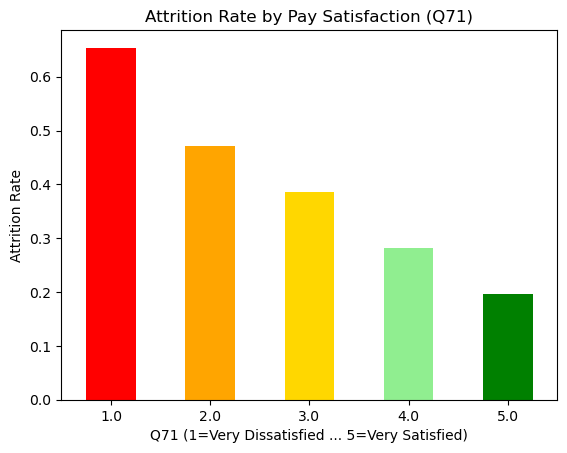

In [12]:
# Attrition Rate by Pay Satisfaction (Q71)
# FEVS coding: 1 = Very Dissatisfied  ...  5 = Very Satisfied
attr_by_pay = df.groupby('Q71')['DLEAVING_BIN'].mean()

# Red = unhappy with pay (left, x=1), Green = happy with pay (right, x=5)
colors = ['red', 'orange', 'gold', 'lightgreen', 'green']
attr_by_pay.plot(kind='bar', color=colors[:len(attr_by_pay)])
plt.title('Attrition Rate by Pay Satisfaction (Q71)')
plt.xlabel('Q71 (1=Very Dissatisfied ... 5=Very Satisfied)')
plt.ylabel('Attrition Rate')
plt.xticks(rotation=0)
plt.show()


In [13]:
#compare salary vs job satisfaction vs leadership (which matters most)
leadership_cols = [f'Q{i}' for i in range(57,66)]
df['leadership_score'] = df[leadership_cols].mean(axis=1)

In [14]:
df[['Q71', 'Q70', 'leadership_score']].corrwith(df['DLEAVING_BIN']).sort_values()
# more negative = stronger factor (reduces leaving)

Q70                -0.439906
leadership_score   -0.347638
Q71                -0.267088
dtype: float64

In [15]:
df.groupby('DLEAVING_BIN')[['Q71', 'Q70', 'leadership_score']].mean()
#Look for: biggest gap between stay vs leave: bigger gap = stronger driver
#And it appears job satisfaction is a stronger attrition driver than leadership and pay.
# People may leave less because they are underpaid, and more because they are unhappy with the job itself or leadership.

,Q71,Q70,leadership_score
DLEAVING_BIN,,,
0,3.748441,4.163243,3.914922
1,3.070192,3.156332,3.189138


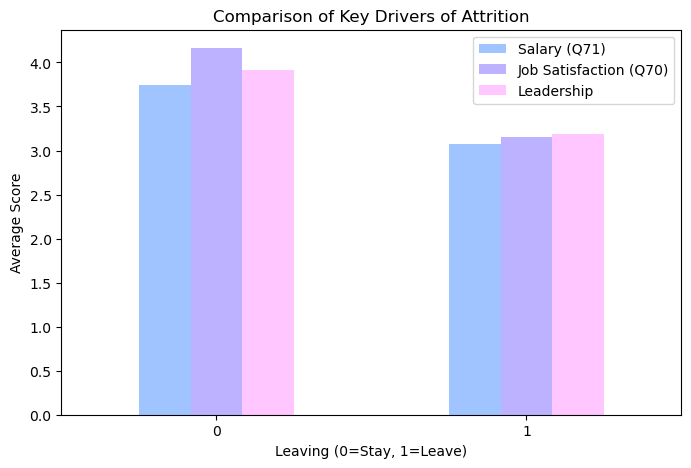

In [16]:
#Plot side by side
compare_df = pd.DataFrame({
    'Salary (Q71)': df.groupby('DLEAVING_BIN')['Q71'].mean(),
    'Job Satisfaction (Q70)': df.groupby('DLEAVING_BIN')['Q70'].mean(),
    'Leadership': df.groupby('DLEAVING_BIN')['leadership_score'].mean()
})

compare_df.plot(kind='bar', figsize=(8,5), color=['#a0c4ff', '#bdb2ff', '#ffc6ff'])

plt.title('Comparison of Key Drivers of Attrition')
plt.ylabel('Average Score')
plt.xlabel('Leaving (0=Stay, 1=Leave)')
plt.xticks(rotation=0)
plt.show()

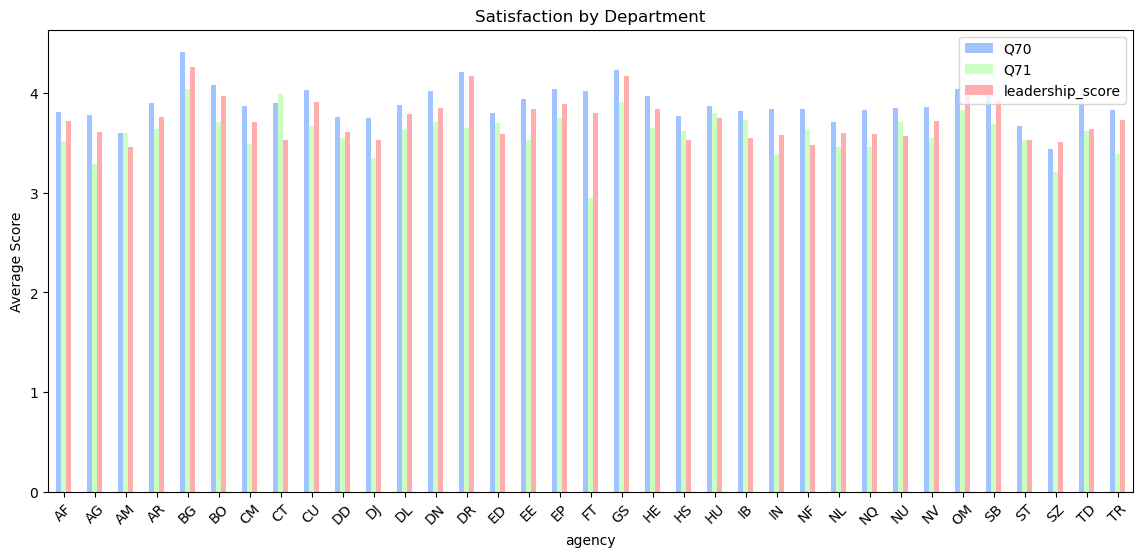

In [17]:
#Satisfaction by Department
dept_compare = df.groupby('agency')[
    ['Q70','Q71','leadership_score']
].mean()

dept_compare.plot(
    kind='bar',
    figsize=(14,6),
    color=['#a0c4ff','#caffbf','#ffadad']
)

plt.title('Satisfaction by Department')
plt.ylabel('Average Score')
plt.xticks(rotation=45)
plt.show()

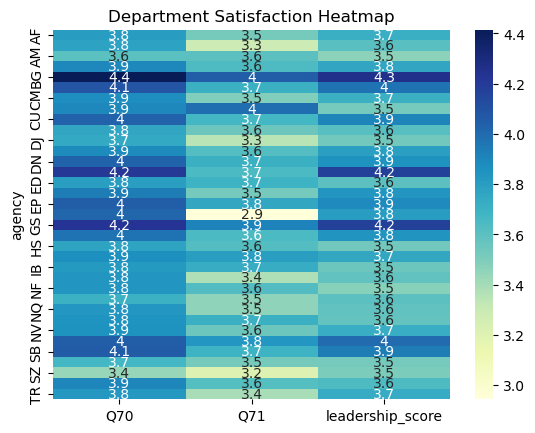

In [18]:
#Heatmap

dept_scores = df.groupby('agency')[
    ['Q70','Q71','leadership_score']
].mean()

sns.heatmap(
    dept_scores,
    cmap='YlGnBu',
    annot=True
)

plt.title('Department Satisfaction Heatmap')
plt.show()

#Questions worth asking

Which departments have lowest satisfaction?

Which have highest attrition?

Does poor leadership line up with attrition?

Is pay dissatisfaction department-specific?

That’s strong HR analytics.

In [19]:
#Attrition by department
top20 = df['agency'].value_counts().head(20).index

df_top20 = df[df['agency'].isin(top20)]

attrition_by_dept = (
    df_top20
    .groupby('agency')['DLEAVING_BIN']
    .mean()
    .sort_values()
)

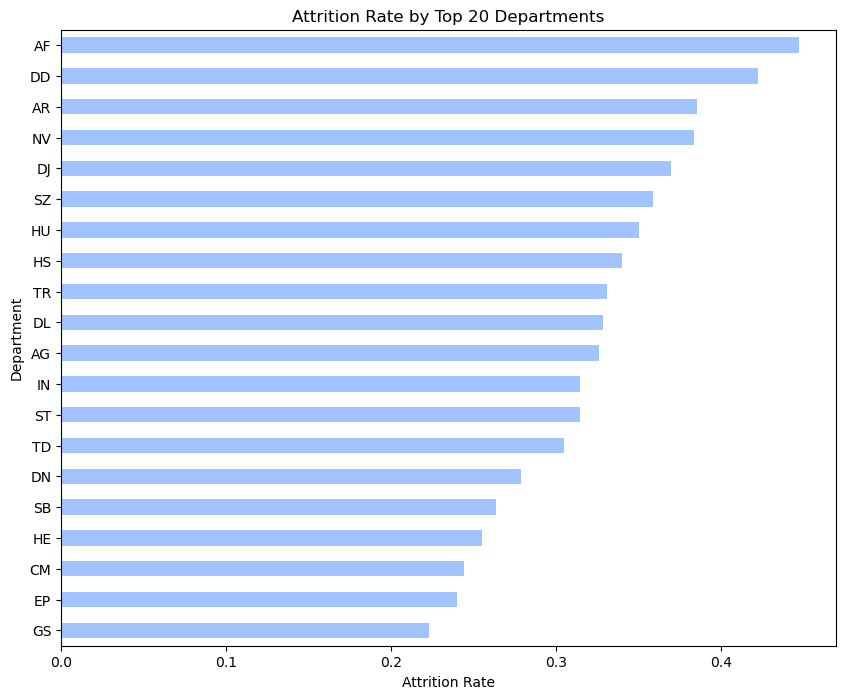

In [20]:
colors = ['#a0c4ff'] * len(attrition_by_dept)

attrition_by_dept.plot(
    kind='barh',
    figsize=(10,8),
    color=colors
)

plt.title('Attrition Rate by Top 20 Departments')
plt.xlabel('Attrition Rate')
plt.ylabel('Department')
plt.show()

In [21]:
#Add satisfaction to attrition
dept_summary = (
    df_top20.groupby('agency')
    .agg({
        'DLEAVING_BIN':'mean',
        'Q70':'mean'
    })
    .sort_values('DLEAVING_BIN')
)

print(dept_summary)

        DLEAVING_BIN       Q70
agency                        
GS          0.222846  4.230377
EP          0.239602  4.043852
CM          0.244250  3.874973
HE          0.254916  3.970629
SB          0.263479  4.057431
DN          0.278695  4.025319
TD          0.304472  3.903555
ST          0.314529  3.669544
IN          0.314572  3.839779
AG          0.325633  3.781891
DL          0.328062  3.882164
TR          0.330619  3.827318
HS          0.339451  3.771310
HU          0.350338  3.866473
SZ          0.358507  3.436336
DJ          0.369184  3.746187
NV          0.383419  3.855290
AR          0.385030  3.895966
DD          0.421854  3.763841
AF          0.447027  3.805174


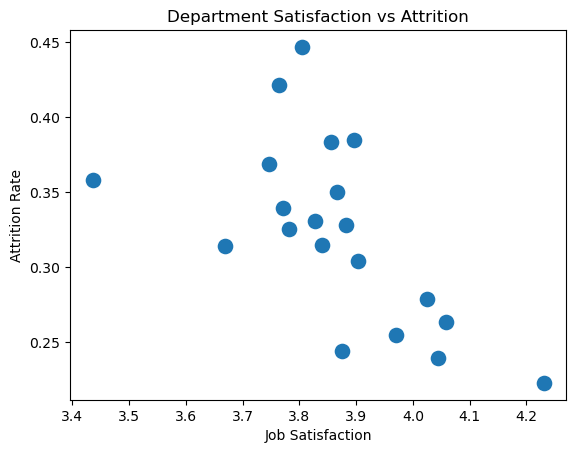

In [22]:
sns.scatterplot(
    data=dept_summary,
    x='Q70',
    y='DLEAVING_BIN',
    s=150
)

plt.title('Department Satisfaction vs Attrition')
plt.xlabel('Job Satisfaction')
plt.ylabel('Attrition Rate')
plt.show()

#Data Processing

Target Questions: Identify drivers of dissatisfaction

Predict employee attrition risk

# Modeling Pipeline: Predicting Employee Attrition

We use two models, chosen for complementary strengths:
- **Logistic Regression** — interpretable baseline; coefficients tell us direction and magnitude per feature.
- **XGBoost (Gradient-Boosted Trees)** — state-of-the-art on tabular data; captures non-linearities and feature interactions; gives gain-based importance.

Target: `DLEAVING_BIN` (0 = Stay, 1 = considering leaving). Features: job satisfaction (Q70), pay satisfaction (Q71), leadership composite, plus demographics.


In [23]:
# Select features for modeling
features = ['Q70', 'Q71', 'leadership_score', 'DSEX', 'DSUPER', 'DFEDTEN', 'DAGEGRP']
X = df[features].copy()
y = df['DLEAVING_BIN']

# Encode categoricals
X = pd.get_dummies(X, drop_first=True)

# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Train shape: (505838, 8), Test shape: (126460, 8)


Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.76      0.90      0.82     83685
           1       0.69      0.45      0.54     42775

    accuracy                           0.75    126460
   macro avg       0.73      0.67      0.68    126460
weighted avg       0.74      0.75      0.73    126460

ROC AUC: 0.764


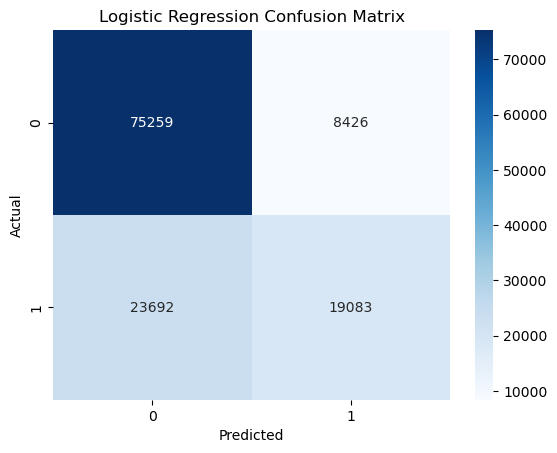

In [24]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
y_prob_lr = logreg.predict_proba(X_test)[:,1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC AUC: {roc_auc_score(y_test, y_prob_lr):.3f}")

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

XGBoost Results:
              precision    recall  f1-score   support

           0       0.81      0.77      0.79     83685
           1       0.59      0.64      0.61     42775

    accuracy                           0.73    126460
   macro avg       0.70      0.70      0.70    126460
weighted avg       0.73      0.73      0.73    126460

ROC AUC: 0.771


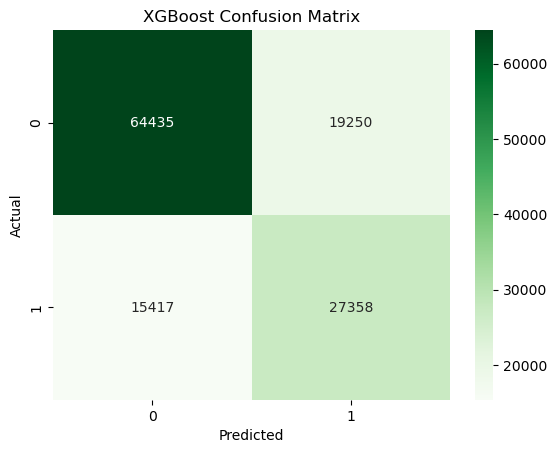

In [25]:
# XGBoost Classifier (replaces Random Forest)
import xgboost as xgb

# scale_pos_weight balances the ~33% positive class without resampling
scale_pos_weight = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.9,
    colsample_bytree=0.9,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    tree_method='hist',
)
xgb_clf.fit(X_train, y_train)

y_pred_xgb = xgb_clf.predict(X_test)
y_prob_xgb = xgb_clf.predict_proba(X_test)[:, 1]

print('XGBoost Results:')
print(classification_report(y_test, y_pred_xgb))
print(f'ROC AUC: {roc_auc_score(y_test, y_prob_xgb):.3f}')

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens')
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


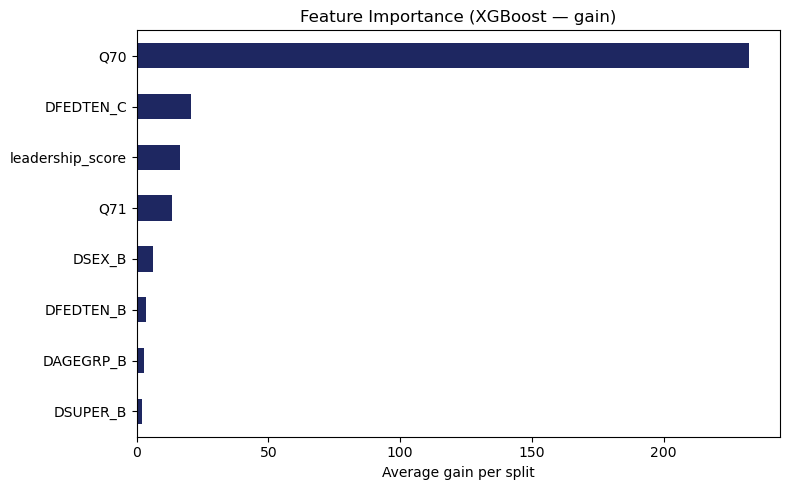

In [26]:
# Feature importance from XGBoost (gain-based — average improvement in loss per split)
importances = pd.Series(
    xgb_clf.get_booster().get_score(importance_type='gain'),
    name='gain',
).reindex(X.columns).fillna(0).sort_values(ascending=True)

importances.plot(kind='barh', figsize=(8, 5), color='#1E2761')
plt.title('Feature Importance (XGBoost — gain)')
plt.xlabel('Average gain per split')
plt.tight_layout()
plt.show()


# Results Summary and Recommendations

- Both models (Logistic Regression and XGBoost) predict attrition with reasonable accuracy on the 20% holdout. XGBoost captures non-linearities and typically edges out the baseline on AUC.
- **Key predictors (XGBoost gain):** job satisfaction (Q70), leadership composite (mean of Q57–Q65), and pay satisfaction (Q71) dominate. Demographic dummies barely register.
- `scale_pos_weight` is set to the class-imbalance ratio so XGBoost does not collapse to predicting “stay” for everyone.
- **Recommendation:** to reduce attrition risk, agencies should focus on job satisfaction, leadership quality, and pay satisfaction — not on demographic targeting.
